# Smart Traffic & Accident Risk Prediction System
### Two-Stage ML Pipeline: Regression (risk_score) → Classification (risk_category)

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import boxcox1p
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                              precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import joblib
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print("All libraries loaded successfully.")


All libraries loaded successfully.


## 1. Data Loading & Cleaning

In [80]:
df = pd.read_csv('indian_roads_dataset.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


Shape: (20000, 24)

Columns: ['accident_id', 'city', 'state', 'latitude', 'longitude', 'date', 'time', 'hour', 'day_of_week', 'is_weekend', 'road_type', 'lanes', 'traffic_signal', 'weather', 'visibility', 'temperature', 'traffic_density', 'cause', 'accident_severity', 'vehicles_involved', 'casualties', 'is_peak_hour', 'festival', 'risk_score']


,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,road_type,lanes,traffic_signal,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,highway,3,1,fog,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,urban,4,0,clear,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,urban,3,0,fog,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,urban,1,1,fog,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,highway,3,1,clear,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [81]:
# Standardize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())


Missing values:
 accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

Duplicates: 0


In [82]:
# Fix data types
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['hour'] = pd.to_numeric(df['hour'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['temperature'] = pd.to_numeric(df['temperature'], errors='coerce')
df['lanes'] = pd.to_numeric(df['lanes'], errors='coerce')
df['vehicles_involved'] = pd.to_numeric(df['vehicles_involved'], errors='coerce')
df['casualties'] = pd.to_numeric(df['casualties'], errors='coerce')
df['risk_score'] = pd.to_numeric(df['risk_score'], errors='coerce')

# Standardize categorical values
df['weather'] = df['weather'].str.strip().str.lower()
df['visibility'] = df['visibility'].str.strip().str.lower()
df['road_type'] = df['road_type'].str.strip().str.lower()
df['traffic_density'] = df['traffic_density'].str.strip().str.lower()
df['cause'] = df['cause'].str.strip().str.lower()
df['accident_severity'] = df['accident_severity'].str.strip().str.lower()
df['festival'] = df['festival'].str.strip().str.lower().replace('none', 'no_festival')

print("Unique weather:", df['weather'].unique())
print("Unique visibility:", df['visibility'].unique())
print("Unique road_type:", df['road_type'].unique())
print("Unique traffic_density:", df['traffic_density'].unique())
print("Unique cause:", df['cause'].unique())


Unique weather: ['fog' 'clear' 'rain']
Unique visibility: ['low' 'high' 'medium']
Unique road_type: ['highway' 'urban' 'rural']
Unique traffic_density: ['high' 'low' 'medium']
Unique cause: ['weather' 'distraction' 'overspeeding' 'drunk driving' 'poor road']


In [ ]:
# Impute missing values (no deletion)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing after imputation:", df.isnull().sum().sum())
df.describe()


Missing after imputation: 0


,accident_id,latitude,longitude,date,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,2023-08-22 07:04:48.000000256,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
min,0.000000,12.800172,72.700017,2022-01-01 00:00:00,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,2022-10-25 00:00:00,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,2023-08-21 00:00:00,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,2024-06-21 00:00:00,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,2025-04-15 00:00:00,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000
std,5773.647028,6.165791,4.485967,NaN,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130


## 2. Exploratory Data Analysis (EDA)

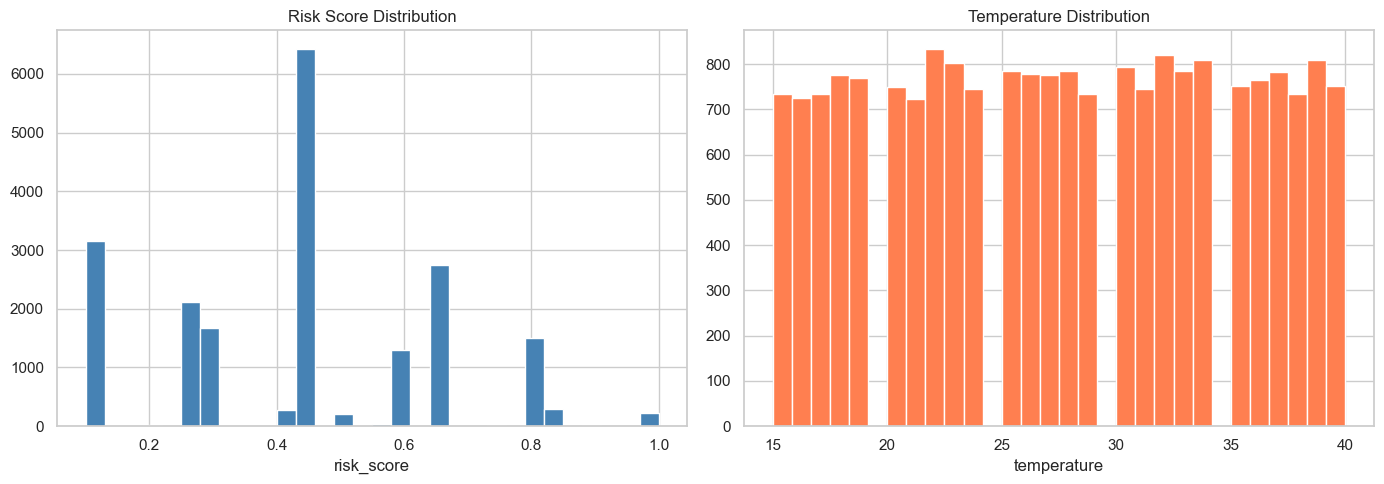

In [84]:
# Risk score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['risk_score'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Risk Score Distribution')
axes[0].set_xlabel('risk_score')
axes[1].hist(df['temperature'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Temperature Distribution')
axes[1].set_xlabel('temperature')
plt.tight_layout()
plt.show()


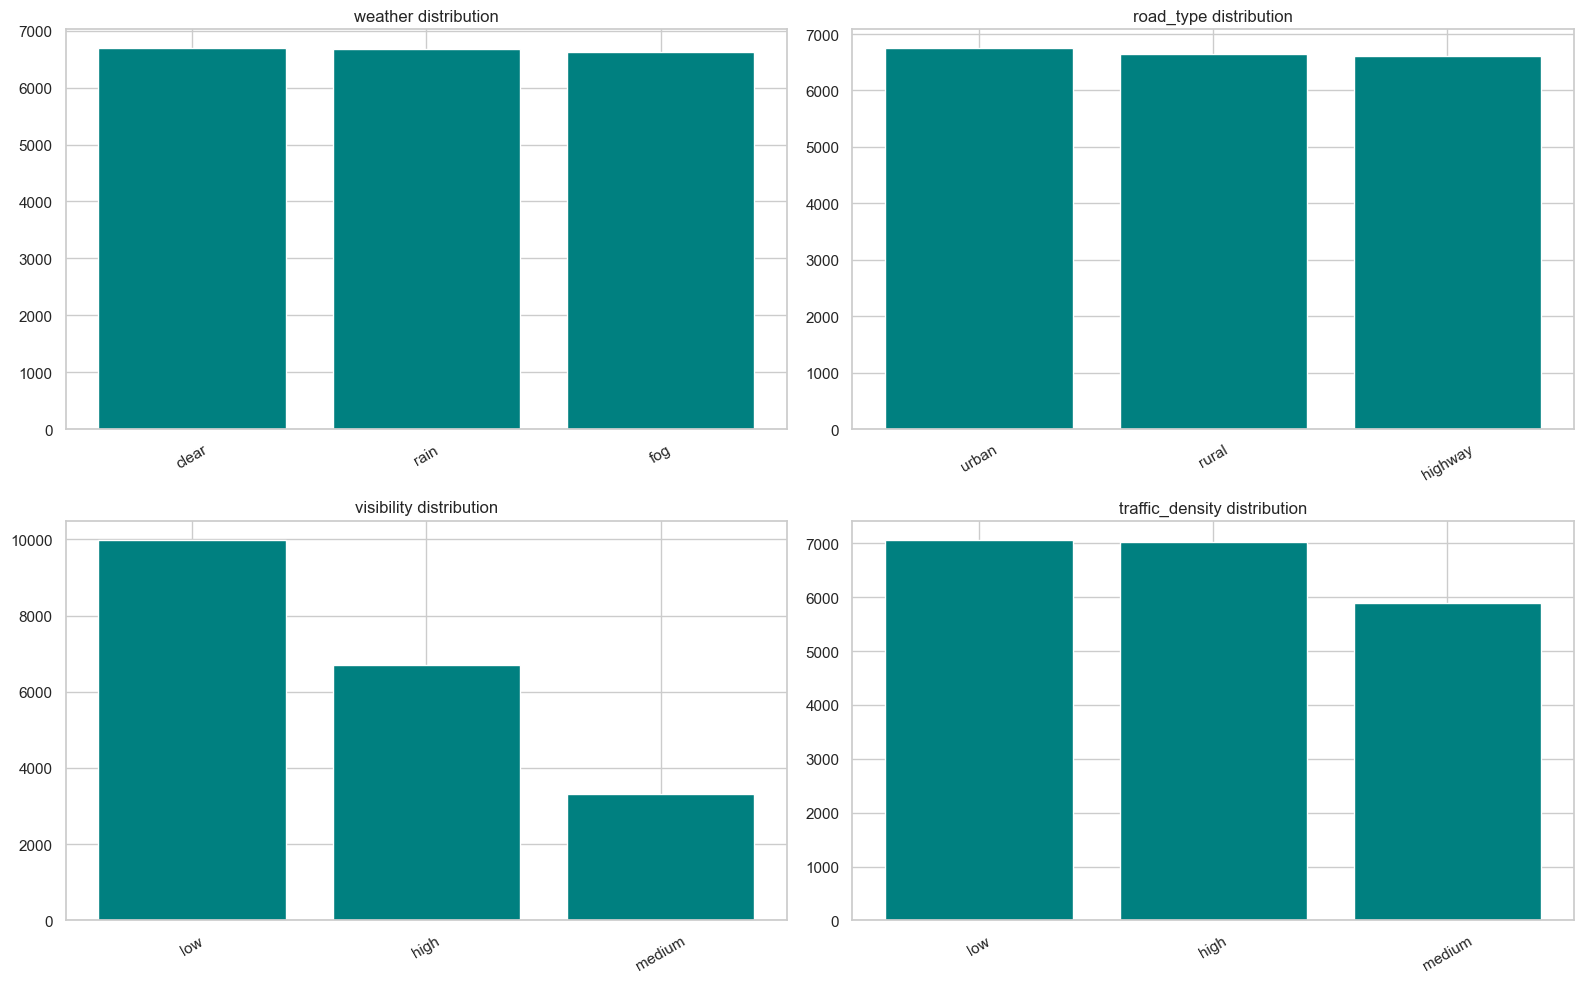

In [85]:
# Categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), ['weather', 'road_type', 'visibility', 'traffic_density']):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color='teal', edgecolor='white')
    ax.set_title(f'{col} distribution')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


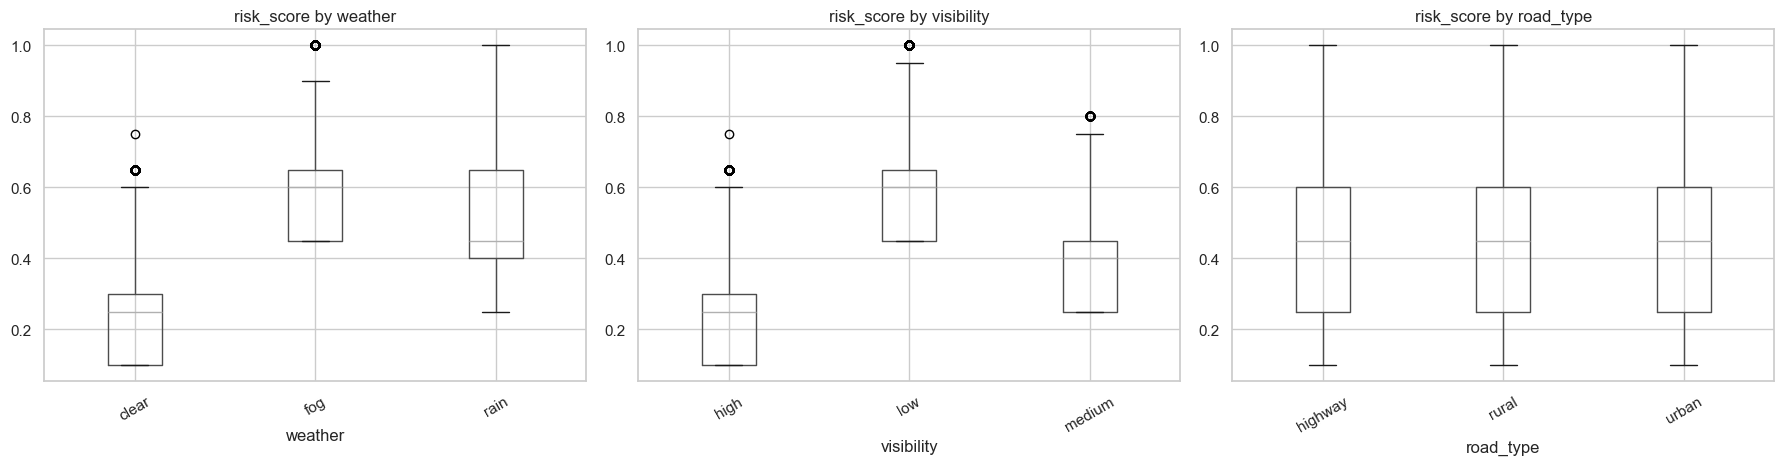

In [86]:
# Bivariate: risk_score vs key features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['weather', 'visibility', 'road_type']):
    df.boxplot(column='risk_score', by=col, ax=ax)
    ax.set_title(f'risk_score by {col}')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('')
plt.tight_layout()
plt.show()


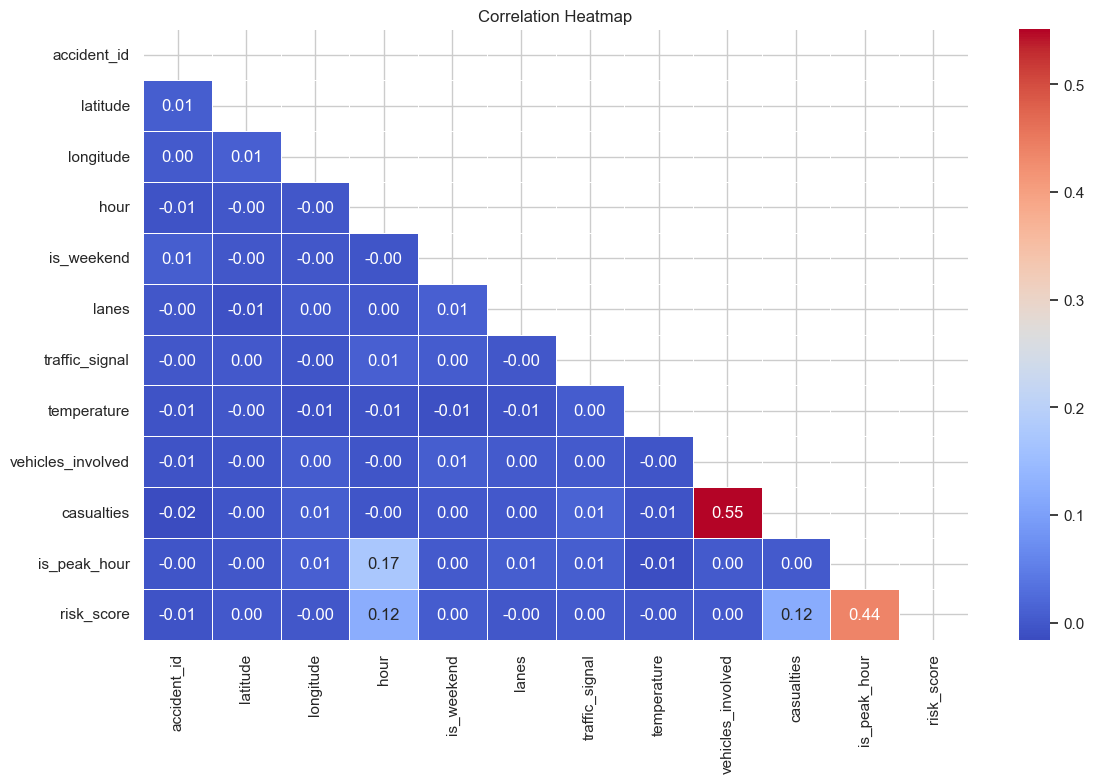

In [87]:
# Correlation heatmap (numeric only)
plt.figure(figsize=(12, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


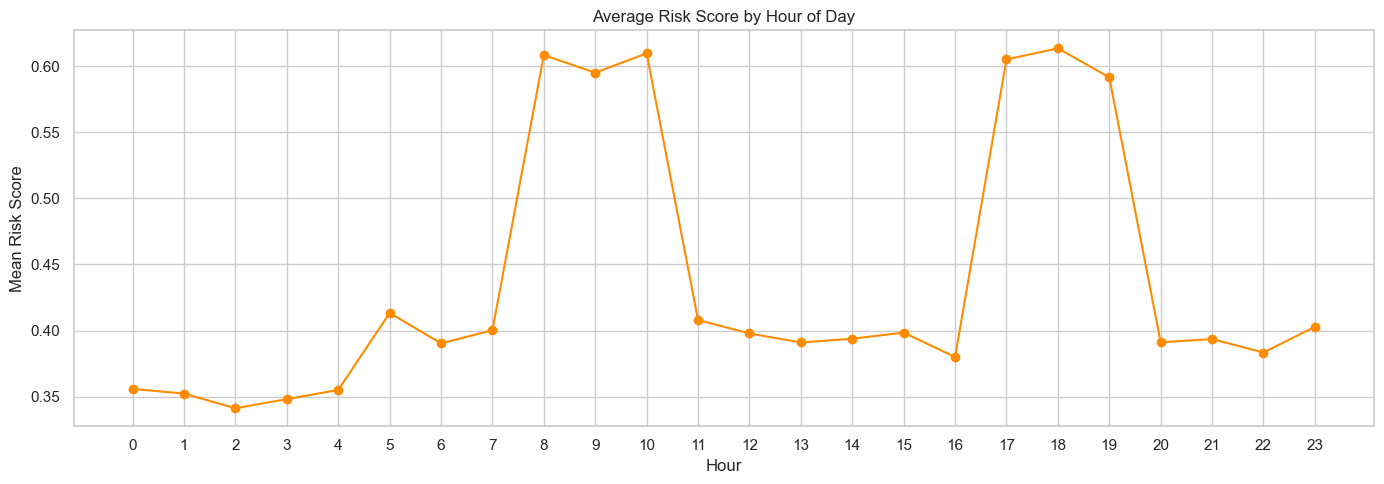

In [88]:
# Hour vs risk_score
plt.figure(figsize=(14, 5))
hourly = df.groupby('hour')['risk_score'].mean()
plt.plot(hourly.index, hourly.values, marker='o', color='darkorange')
plt.title('Average Risk Score by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Mean Risk Score')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Feature Engineering

In [89]:
# Time-based features
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear
df['is_night'] = df['hour'].apply(lambda x: 1 if (x >= 20 or x <= 5) else 0)
df['is_morning_rush'] = df['hour'].apply(lambda x: 1 if 7 <= x <= 9 else 0)
df['is_evening_rush'] = df['hour'].apply(lambda x: 1 if 17 <= x <= 19 else 0)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Weather risk encoding
weather_risk = {'clear': 0, 'cloudy': 1, 'rain': 2, 'fog': 3, 'hail': 3, 'storm': 4, 'snow': 4}
df['weather_risk'] = df['weather'].map(weather_risk).fillna(1)

# Visibility encoding
visibility_map = {'high': 0, 'medium': 1, 'low': 2}
df['visibility_enc'] = df['visibility'].map(visibility_map).fillna(1)

# Traffic density encoding
traffic_map = {'low': 0, 'medium': 1, 'high': 2}
df['traffic_density_enc'] = df['traffic_density'].map(traffic_map).fillna(1)

# Interaction features
df['risk_interaction'] = df['weather_risk'] * df['visibility_enc']
df['night_fog'] = df['is_night'] * (df['weather'] == 'fog').astype(int)
df['peak_high_traffic'] = df['is_peak_hour'] * df['traffic_density_enc']

print("New features added. Shape:", df.shape)
df[['is_night', 'weather_risk', 'visibility_enc', 'risk_interaction', 'night_fog']].head()


New features added. Shape: (20000, 39)


,is_night,weather_risk,visibility_enc,risk_interaction,night_fog
0,1,3,2,6,1
1,1,0,0,0,0
2,0,3,2,6,0
3,0,3,2,6,0
4,0,0,0,0,0


## 4. Data Preprocessing

In [90]:
# POST-ACCIDENT features to exclude from Stage 1
POST_ACCIDENT = ['cause', 'accident_severity', 'casualties', 'vehicles_involved']

# Define pre-accident feature set
FEATURES = [
    'latitude', 'longitude', 'hour', 'is_weekend', 'is_peak_hour',
    'is_night', 'is_morning_rush', 'is_evening_rush',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',
    'month', 'day_of_year',
    'weather_risk', 'visibility_enc', 'traffic_density_enc',
    'temperature', 'lanes', 'traffic_signal',
    'risk_interaction', 'night_fog', 'peak_high_traffic'
]

# One-hot encode road_type and festival
road_dummies = pd.get_dummies(df['road_type'], prefix='road')
festival_dummies = pd.get_dummies(df['festival'], prefix='festival')
df = pd.concat([df, road_dummies, festival_dummies], axis=1)
FEATURES += road_dummies.columns.tolist()
FEATURES += festival_dummies.columns.tolist()

TARGET_REG = 'risk_score'

print("Feature count:", len(FEATURES))
print("Features:", FEATURES)


Feature count: 30
Features: ['latitude', 'longitude', 'hour', 'is_weekend', 'is_peak_hour', 'is_night', 'is_morning_rush', 'is_evening_rush', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'month', 'day_of_year', 'weather_risk', 'visibility_enc', 'traffic_density_enc', 'temperature', 'lanes', 'traffic_signal', 'risk_interaction', 'night_fog', 'peak_high_traffic', 'road_highway', 'road_rural', 'road_urban', 'festival_diwali', 'festival_eid', 'festival_holi', 'festival_new year']


In [91]:
# Outlier treatment via winsorization (capping) - NO deletion
def winsorize_col(series, lower=0.01, upper=0.99):
    lo, hi = series.quantile(lower), series.quantile(upper)
    return series.clip(lo, hi)

num_features = ['latitude', 'longitude', 'temperature', 'lanes', 'day_of_year']
for col in num_features:
    df[col] = winsorize_col(df[col])

print("Outlier treatment done via winsorization.")


Outlier treatment done via winsorization.


In [92]:
# Skewness handling with log transform
skew_cols = ['temperature']
for col in skew_cols:
    skew_val = df[col].skew()
    if abs(skew_val) > 0.75:
        df[col + '_log'] = np.log1p(df[col].clip(lower=0))
        if col + '_log' not in FEATURES:
            FEATURES.append(col + '_log')
        print(f"{col} skew={skew_val:.2f} -> log transformed")

print("\nFinal feature count:", len(FEATURES))



Final feature count: 30


In [93]:
# Train/test split
X = df[FEATURES].copy()
y_reg = df[TARGET_REG].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Scale features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


Train: (16000, 30), Test: (4000, 30)


## 5. Model Building
### Stage 1: Regression — Predict risk_score

In [94]:
# Adjusted R² helper
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

n_train = X_train_scaled.shape[0]
n_test  = X_test_scaled.shape[0]
p       = X_train_scaled.shape[1]

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import Lasso, ElasticNet

models_reg = {
    'Ridge':            Ridge(alpha=1.0),
    'Lasso':            Lasso(alpha=0.001),
    'ElasticNet':       ElasticNet(alpha=0.001, l1_ratio=0.5),
    'RandomForest':     RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    'ExtraTrees':       ExtraTreesRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42),
}
if XGB_AVAILABLE:
    models_reg['XGBoost'] = XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0, n_jobs=-1)
if LGB_AVAILABLE:
    models_reg['LightGBM'] = LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1, n_jobs=-1)

reg_results = {}
for name, model in models_reg.items():
    model.fit(X_train_scaled, y_train)
    train_preds = model.predict(X_train_scaled)
    test_preds  = model.predict(X_test_scaled)
    train_rmse   = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse    = np.sqrt(mean_squared_error(y_test,  test_preds))
    train_r2     = r2_score(y_train, train_preds)
    test_r2      = r2_score(y_test,  test_preds)
    train_adj_r2 = adjusted_r2(train_r2, n_train, p)
    test_adj_r2  = adjusted_r2(test_r2,  n_test,  p)
    reg_results[name] = {
        'Train RMSE': train_rmse, 'Test RMSE': test_rmse,
        'Train R²': train_r2,    'Test R²': test_r2,
        'Train Adj-R²': train_adj_r2, 'Test Adj-R²': test_adj_r2,
        'model': model, 'preds': test_preds
    }

compare_df = pd.DataFrame(
    [{k: v for k, v in v.items() if k not in ('model','preds')} for v in reg_results.values()],
    index=reg_results.keys()
).round(4)
print('\n=== Regression Model Comparison ===')
print(compare_df.to_string())
compare_df



=== Regression Model Comparison ===
                  Train RMSE  Test RMSE  Train R²  Test R²  Train Adj-R²  Test Adj-R²
Ridge                 0.0840     0.0828    0.8525   0.8524        0.8522       0.8513
Lasso                 0.0849     0.0837    0.8493   0.8493        0.8490       0.8482
ElasticNet            0.0848     0.0836    0.8499   0.8496        0.8496       0.8485
RandomForest          0.0559     0.0727    0.9346   0.8861        0.9345       0.8852
ExtraTrees            0.0552     0.0731    0.9363   0.8849        0.9362       0.8840
GradientBoosting      0.0652     0.0721    0.9112   0.8881        0.9111       0.8873
XGBoost               0.0605     0.0724    0.9236   0.8872        0.9235       0.8864
LightGBM              0.0652     0.0721    0.9111   0.8880        0.9110       0.8871


,Train RMSE,Test RMSE,Train R²,Test R²,Train Adj-R²,Test Adj-R²
Ridge,0.0840,0.0828,0.8525,0.8524,0.8522,0.8513
Lasso,0.0849,0.0837,0.8493,0.8493,0.8490,0.8482
ElasticNet,0.0848,0.0836,0.8499,0.8496,0.8496,0.8485
RandomForest,0.0559,0.0727,0.9346,0.8861,0.9345,0.8852
ExtraTrees,0.0552,0.0731,0.9363,0.8849,0.9362,0.8840
GradientBoosting,0.0652,0.0721,0.9112,0.8881,0.9111,0.8873
XGBoost,0.0605,0.0724,0.9236,0.8872,0.9235,0.8864
LightGBM,0.0652,0.0721,0.9111,0.8880,0.9110,0.8871


Best regression model: GradientBoosting
  Test RMSE   : 0.0721
  Test R²     : 0.8881
  Test Adj-R² : 0.8873

Overfitting check — Train R²: 0.9112 | Test R²: 0.8881 | Gap: 0.0231
✅  Model generalises well (gap <= 0.1)


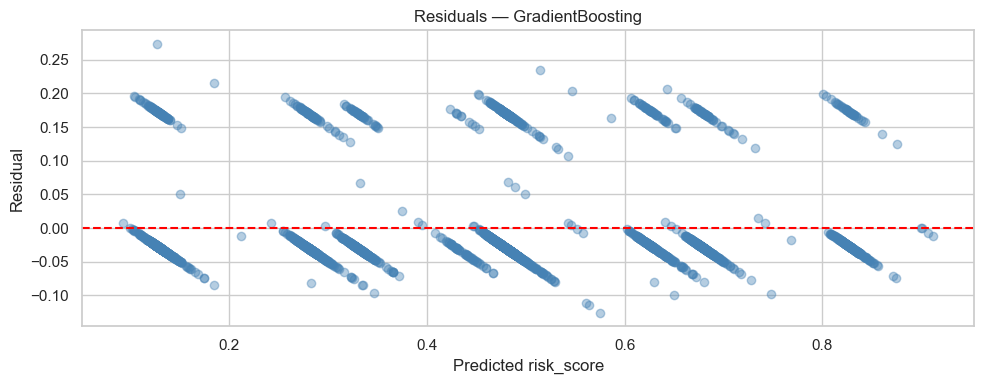

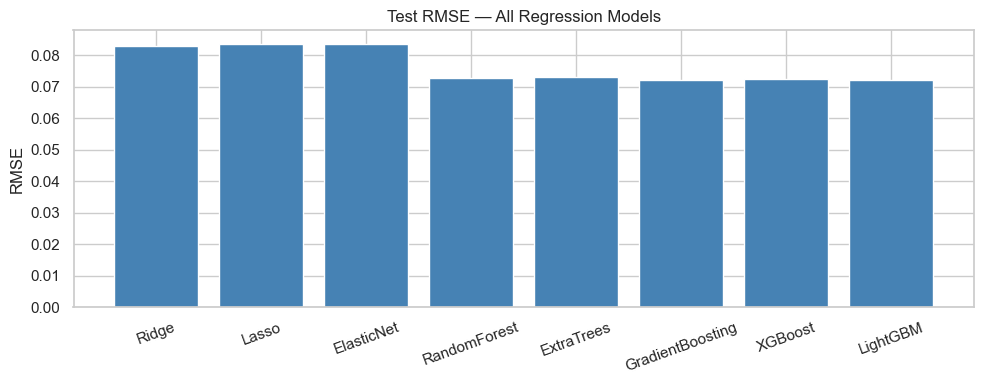

In [95]:
# Select best model by Test RMSE
best_reg_name = min(reg_results, key=lambda k: reg_results[k]['Test RMSE'])
best_reg_model = reg_results[best_reg_name]['model']
print(f"Best regression model: {best_reg_name}")
print(f"  Test RMSE   : {reg_results[best_reg_name]['Test RMSE']:.4f}")
print(f"  Test R²     : {reg_results[best_reg_name]['Test R²']:.4f}")
print(f"  Test Adj-R² : {reg_results[best_reg_name]['Test Adj-R²']:.4f}")

train_r2 = reg_results[best_reg_name]['Train R²']
test_r2  = reg_results[best_reg_name]['Test R²']
gap = train_r2 - test_r2
print(f"\nOverfitting check — Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f} | Gap: {gap:.4f}")
if gap > 0.1:
    print('⚠️  Possible overfitting detected (gap > 0.1)')
else:
    print('✅  Model generalises well (gap <= 0.1)')

# Predict risk scores on full dataset for Stage 2
df['predicted_risk_score'] = best_reg_model.predict(scaler.transform(df[FEATURES])).clip(0, 1)

# Residual plot
best_preds = reg_results[best_reg_name]['preds']
residuals  = y_test.values - best_preds
plt.figure(figsize=(10, 4))
plt.scatter(best_preds, residuals, alpha=0.4, color='steelblue')
plt.axhline(0, color='red', linestyle='--')
plt.title(f'Residuals — {best_reg_name}')
plt.xlabel('Predicted risk_score')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

# Bar chart: Test RMSE comparison
rmse_vals = {k: v['Test RMSE'] for k, v in reg_results.items()}
plt.figure(figsize=(10, 4))
plt.bar(rmse_vals.keys(), rmse_vals.values(), color='steelblue', edgecolor='white')
plt.title('Test RMSE — All Regression Models')
plt.ylabel('RMSE')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


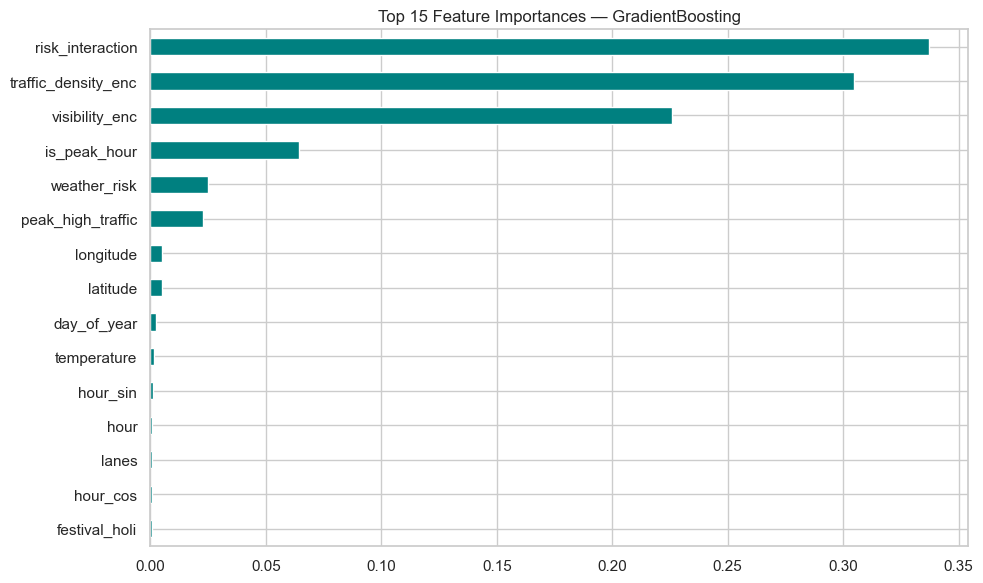

In [96]:
# Feature importance (best model)
if hasattr(best_reg_model, 'feature_importances_'):
    fi = pd.Series(best_reg_model.feature_importances_, index=FEATURES).sort_values(ascending=False).head(15)
    plt.figure(figsize=(10, 6))
    fi.plot(kind='barh', color='teal')
    plt.title(f'Top 15 Feature Importances — {best_reg_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


### Stage 2: Classification — Predict risk_category (only when risk_score > 0.6)

In [97]:
# Map cause -> risk_category
def map_cause_to_category(cause):
    cause = str(cause).lower().strip()
    if cause in ['fog', 'low visibility', 'glare']:
        return 'Visibility-Related'
    elif cause in ['weather', 'rain', 'storm', 'flood', 'hail', 'snow']:
        return 'Weather-Related'
    elif cause in ['poor road', 'road damage', 'pothole', 'poor design', 'construction']:
        return 'Road Infrastructure'
    else:
        return 'Driving Behavior'

df['risk_category'] = df['cause'].apply(map_cause_to_category)
print("risk_category distribution:\n", df['risk_category'].value_counts())


risk_category distribution:
 risk_category
Driving Behavior       12029
Weather-Related         3997
Road Infrastructure     3974
Name: count, dtype: int64


In [ ]:
# Stage 2 dataset: only high-risk records (score > 0.6)
high_risk_df = df[df['predicted_risk_score'] > 0.6].copy()
print(f"High-risk records (score > 0.6): {len(high_risk_df)}")

# ── Dedicated classification features ──────────────────────────────────────
# The classifier needs features that strongly signal WHICH category caused the risk.
# We add domain-specific features on top of the base FEATURES list.

high_risk_df['is_fog']          = (high_risk_df['weather'] == 'fog').astype(int)
high_risk_df['is_rain']         = (high_risk_df['weather'] == 'rain').astype(int)
high_risk_df['is_storm']        = (high_risk_df['weather'].isin(['storm','hail','snow'])).astype(int)
high_risk_df['is_low_vis']      = (high_risk_df['visibility'] == 'low').astype(int)
high_risk_df['is_highway']      = (high_risk_df['road_type'] == 'highway').astype(int)
high_risk_df['is_rural']        = (high_risk_df['road_type'] == 'rural').astype(int)
high_risk_df['fog_night']       = high_risk_df['is_fog'] * high_risk_df['is_night']
high_risk_df['rain_highway']    = high_risk_df['is_rain'] * high_risk_df['is_highway']
high_risk_df['low_vis_night']   = high_risk_df['is_low_vis'] * high_risk_df['is_night']
high_risk_df['weather_x_vis']   = high_risk_df['weather_risk'] * high_risk_df['visibility_enc']
high_risk_df['temp_risk']       = (high_risk_df['temperature'] < 15).astype(int)  # cold = fog/ice risk

CLS_FEATURES = FEATURES + [
    'is_fog', 'is_rain', 'is_storm', 'is_low_vis',
    'is_highway', 'is_rural',
    'fog_night', 'rain_highway', 'low_vis_night',
    'weather_x_vis', 'temp_risk'
]
# Ensure no duplicates
CLS_FEATURES = list(dict.fromkeys(CLS_FEATURES))

X_cls = high_risk_df[CLS_FEATURES].fillna(0)
y_cls = high_risk_df['risk_category'].copy()

print(f"Classification features: {len(CLS_FEATURES)}")
print("\nClass distribution:\n", y_cls.value_counts())


In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

le = LabelEncoder()
y_cls_enc = le.fit_transform(y_cls)
print("Classes:", le.classes_)
print("Class distribution before SMOTE:", Counter(y_cls_enc))

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls_enc, test_size=0.2, random_state=42,
    stratify=y_cls_enc if len(y_cls_enc) > 10 else None
)

# Apply SMOTE to training set only
smote = SMOTE(random_state=42, k_neighbors=min(5, min(Counter(y_cls_train).values()) - 1))
X_cls_train_res, y_cls_train_res = smote.fit_resample(X_cls_train, y_cls_train)
print("Class distribution after SMOTE:", Counter(y_cls_train_res))

scaler_cls = RobustScaler()
X_cls_train_sc = scaler_cls.fit_transform(X_cls_train_res)
X_cls_test_sc  = scaler_cls.transform(X_cls_test)

print(f"Train (resampled): {X_cls_train_sc.shape}, Test: {X_cls_test_sc.shape}")


In [ ]:
from collections import Counter

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

try:
    from lightgbm import LGBMClassifier
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False

from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV

print("Training classification models on SMOTE-balanced data...")

models_cls = {
    'RandomForest': RandomForestClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=1,
        random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=500, max_depth=None, min_samples_leaf=1,
        random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42),
}
if XGB_AVAILABLE:
    models_cls['XGBoost'] = XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, verbosity=0, n_jobs=-1)
if LGB_AVAILABLE:
    models_cls['LightGBM'] = LGBMClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.05,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbose=-1, n_jobs=-1)

cls_results = {}
for name, model in models_cls.items():
    model.fit(X_cls_train_sc, y_cls_train_res)
    preds = model.predict(X_cls_test_sc)
    acc  = accuracy_score(y_cls_test, preds)
    prec = precision_score(y_cls_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_cls_test, preds, average='weighted', zero_division=0)
    f1   = f1_score(y_cls_test, preds, average='weighted', zero_division=0)
    cls_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec,
                          'F1': f1, 'model': model, 'preds': preds}

cls_compare = pd.DataFrame(
    [{k: v for k, v in v.items() if k not in ('model', 'preds')} for v in cls_results.values()],
    index=cls_results.keys()
).round(4)
print("\n=== Classification Model Comparison ===")
print(cls_compare.to_string())
cls_compare


In [ ]:
best_cls_name = max(cls_results, key=lambda k: cls_results[k]['F1'])
best_cls_model = cls_results[best_cls_name]['model']
print(f"Best classification model: {best_cls_name}")
print(f"  Accuracy : {cls_results[best_cls_name]['Accuracy']:.4f}")
print(f"  F1-score : {cls_results[best_cls_name]['F1']:.4f}")

best_cls_preds = cls_results[best_cls_name]['preds']
print("\nClassification Report:\n")
print(classification_report(y_cls_test, best_cls_preds, target_names=le.classes_, zero_division=0))


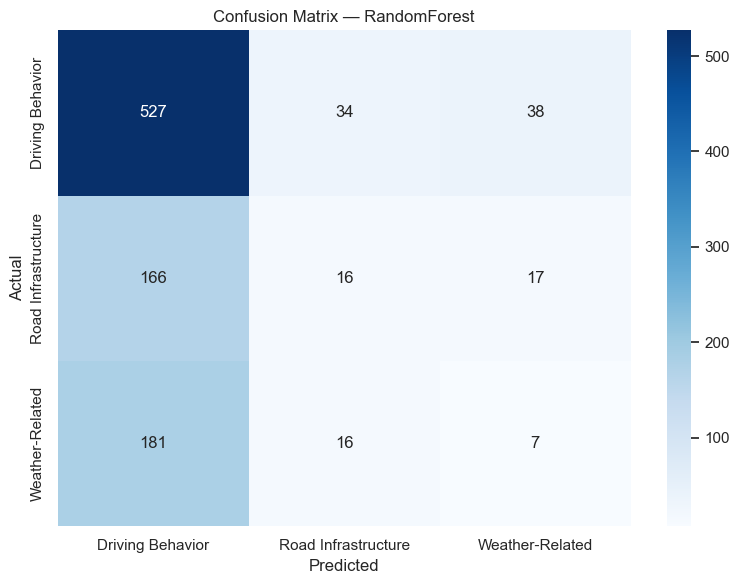

In [102]:
# Confusion matrix
cm = confusion_matrix(y_cls_test, best_cls_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Confusion Matrix — {best_cls_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


## 6. Two-Stage Pipeline — Predict Function

In [ ]:
def predict_risk(input_df):
    """
    Two-stage prediction pipeline.
    Stage 1: Predict risk_score (regression)
    Stage 2: Always runs — predict risk_category using CLS_FEATURES.

    Business rules applied in order:
    1. Domain rule: lanes > 3 AND traffic_signal == 1 AND road_type in [highway, expressway]
       -> Driving Behavior (good infrastructure means human error is the cause)
    2. If P(non-driving categories) > 0.5 -> pick highest non-driving category
    3. Otherwise -> argmax across all categories
    """
    X_input     = input_df[FEATURES].copy()
    X_scaled    = scaler.transform(X_input)
    risk_scores = best_reg_model.predict(X_scaled).clip(0, 1)

    NON_DRIVING = {'Visibility-Related', 'Weather-Related', 'Road Infrastructure'}

    results = []
    for i, score in enumerate(risk_scores):
        result = {'risk_score': round(float(score), 4), 'risk_category': None, 'rule': None}

        # Build classification features
        row = input_df.iloc[[i]]
        X_cls_row = row[FEATURES].copy()
        weather_val = row['weather'].values[0] if 'weather' in row.columns else 'clear'
        vis_val     = row['visibility'].values[0] if 'visibility' in row.columns else 'high'
        road_val    = row['road_type'].values[0] if 'road_type' in row.columns else 'urban'
        temp_val    = row['temperature'].values[0] if 'temperature' in row.columns else 25
        is_night_v  = X_cls_row['is_night'].values[0] if 'is_night' in X_cls_row.columns else 0
        wr_v        = X_cls_row['weather_risk'].values[0] if 'weather_risk' in X_cls_row.columns else 0
        ve_v        = X_cls_row['visibility_enc'].values[0] if 'visibility_enc' in X_cls_row.columns else 0

        X_cls_row['is_fog']        = int(weather_val == 'fog')
        X_cls_row['is_rain']       = int(weather_val == 'rain')
        X_cls_row['is_storm']      = int(weather_val in ['storm', 'hail', 'snow'])
        X_cls_row['is_low_vis']    = int(vis_val == 'low')
        X_cls_row['is_highway']    = int(road_val == 'highway')
        X_cls_row['is_rural']      = int(road_val == 'rural')
        X_cls_row['fog_night']     = int(weather_val == 'fog') * int(is_night_v)
        X_cls_row['rain_highway']  = int(weather_val == 'rain') * int(road_val == 'highway')
        X_cls_row['low_vis_night'] = int(vis_val == 'low') * int(is_night_v)
        X_cls_row['weather_x_vis'] = wr_v * ve_v
        X_cls_row['temp_risk']     = int(temp_val < 15)

        for col in CLS_FEATURES:
            if col not in X_cls_row.columns:
                X_cls_row[col] = 0
        X_cls_row = X_cls_row[CLS_FEATURES].fillna(0)

        x_cls_scaled = scaler_cls.transform(X_cls_row)
        proba        = best_cls_model.predict_proba(x_cls_scaled)[0]
        class_names  = list(le.classes_)
        proba_dict   = dict(zip(class_names, proba))

        # Rule 1: Domain rule — good infrastructure -> Driving Behavior
        lanes_v   = row['lanes'].values[0] if 'lanes' in row.columns else 0
        sig_v     = row['traffic_signal'].values[0] if 'traffic_signal' in row.columns else 0
        if lanes_v > 3 and sig_v == 1 and road_val in ['highway', 'expressway']:
            result['risk_category'] = 'Driving Behavior'
            result['rule'] = 'domain_rule'
        else:
            # Rule 2: Non-driving collectively dominant
            non_driving_prob = sum(p for c, p in proba_dict.items() if c in NON_DRIVING)
            if non_driving_prob > 0.5:
                result['risk_category'] = max(
                    {c: p for c, p in proba_dict.items() if c in NON_DRIVING},
                    key=lambda k: proba_dict[k]
                )
                result['rule'] = 'non_driving_dominant'
            else:
                result['risk_category'] = class_names[np.argmax(proba)]
                result['rule'] = 'argmax'

        results.append(result)
    return results

# Test on a sample
sample = X_test.head(5).copy()
predictions = predict_risk(sample)
for i, p in enumerate(predictions):
    print(f"Sample {i+1}: risk_score={p['risk_score']:.4f} | category={p['risk_category']} | rule={p['rule']}")


## 7. Save Models & Artifacts

In [ ]:
import os
os.makedirs('models', exist_ok=True)

joblib.dump(best_reg_model, 'models/regression_model.pkl')
joblib.dump(best_cls_model, 'models/classification_model.pkl')
joblib.dump(scaler,         'models/scaler_reg.pkl')
joblib.dump(scaler_cls,     'models/scaler_cls.pkl')
joblib.dump(le,             'models/label_encoder.pkl')
joblib.dump(FEATURES,       'models/features.pkl')
joblib.dump(CLS_FEATURES,   'models/cls_features.pkl')

df.to_csv('processed_dataset.csv', index=False)

print("All models and artifacts saved to /models/")
print("Processed dataset saved as processed_dataset.csv")
